# Financial Econometrics: Modeling Volatility.


$$\text{Prepared by: Davison Zhou}$$
$$\text{Registration Number: R2420910}$$
$$\text{Assignment 1}$$




**Environment Setup and Data Extraction**

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error

ticker = 'AAPL'
start_date = '2018-01-01'
end_date = '2025-12-31'

print(f"Downloading data for {ticker}...\n")
aapl_data = yf.download(ticker, start=start_date, end=end_date)

aapl_data['Returns'] = aapl_data['Close'].pct_change()

aapl_data.dropna(inplace=True)

total_observations = len(aapl_data)

date_start = aapl_data.index.min().strftime('%Y-%m-%d')
date_end = aapl_data.index.max().strftime('%Y-%m-%d')

returns_clean = aapl_data['Returns'].dropna()
adf_result = adfuller(returns_clean)

adf_statistic = adf_result[0]
adf_p_value = adf_result[1]

print(f"Total Observations: {total_observations}")
print(f"Date range: {date_start} to {date_end}")
print(f"ADF Test Statistic: {adf_statistic:.4f}")
print(f"ADF P-Value: {adf_p_value:.4f}")

/tmp/ipykernel_1623/30226054.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Total Observations: 2009
Date range: 2018-01-03 to 2025-12-30
ADF Test Statistic: -14.8106
ADF P-Value: 0.0000



### 1. Multicollinearity

**Definition**
Multicollinearity exists in a multiple regression model when two or more independent variables are exactly (or approximately) linearly related. Mathematically, for a set of predictor variables $X_1, X_2, \dots, X_k$, perfect multicollinearity occurs when there exist constants $\lambda_1, \lambda_2, \dots, \lambda_k$ (not all zero) such that:


$$\lambda_1 X_1 + \lambda_2 X_2 + \dots + \lambda_k X_k = 0$$


In practical financial econometrics, we usually deal with *approximate* multicollinearity, where the above equation equals an error term $\epsilon$ rather than exactly zero.

**Description**
Multicollinearity occurs when two or more independent factors in your model are highly correlated with each other. In the context of volatility modeling, this means your inputs carry overlapping information, making it nearly impossible for the model to isolate the individual, independent effect of each factor on the asset's risk.

**Demonstration & Diagram (Python Code)**
To demonstrate this with our AAPL data, let's imagine a naive quant on your desk tries to predict daily volatility (squared returns) using Apple's Open, High, and Low prices, along with Volume. Because Open, High, and Low track the exact same asset on the same day, they will carry overlapping information.


--- Demonstration: Variance Inflation Factor (VIF) ---
Rule of thumb: A VIF > 10 indicates severe multicollinearity.

       Feature         VIF
  (Open, AAPL) 2970.612607
  (High, AAPL) 2478.829928
   (Low, AAPL) 2755.744515
(Volume, AAPL)    1.949920


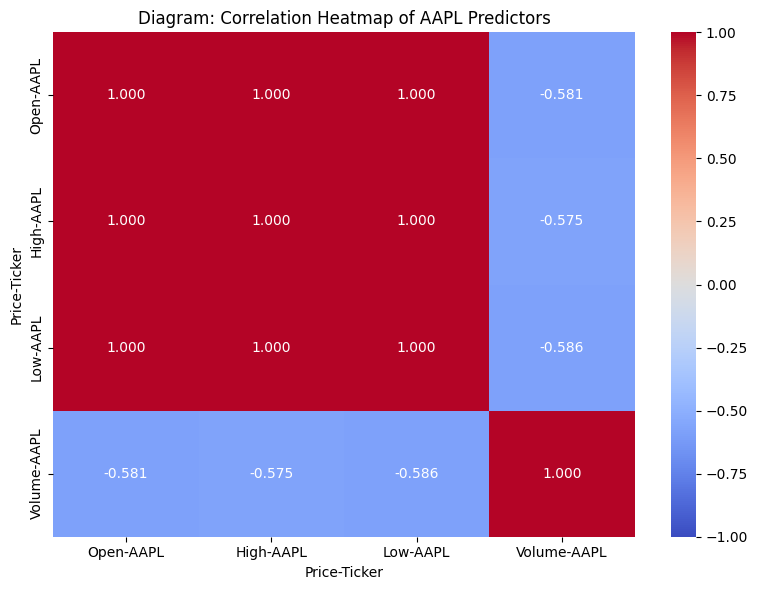

In [ ]:
df = aapl_data.copy()
# Using Open, High, Low, and Volume as our predictors
X = df[['Open', 'High', 'Low', 'Volume']]
X_with_const = sm.add_constant(X)

# DEMONSTRATION: Numerical Example (Variance Inflation Factor)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(X_with_const.shape[1])]

print("--- Demonstration: Variance Inflation Factor (VIF) ---")
print("Rule of thumb: A VIF > 10 indicates severe multicollinearity.\n")
print(vif_data[vif_data['Feature'] != 'const'].to_string(index=False))

# DIAGRAM: Visual Example (Correlation Heatmap)

plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title("Diagram: Correlation Heatmap of AAPL Predictors")
plt.tight_layout()
plt.show()


**Diagnosis**
To recognize that this problem exists, you look for two primary indicators:

1. **Variance Inflation Factor (VIF):** A VIF value quantifies how much the variance of an estimated regression coefficient is increased because of collinearity. A VIF greater than 10 suggests severe multicollinearity. (As you will see in the code output, Open, High, and Low will have massive VIF scores).
2. **Correlation Matrix:** Examine the pairwise correlations between independent variables. Absolute values closer to 1 (e.g., $> 0.80$) typically indicate a problem, which is visibly obvious in the heatmap diagram.

**Damage**
Multicollinearity inflates the standard errors of the regression coefficients. While it doesn't reduce the predictive power of the model as a whole, it makes the coefficient estimates highly erratic and sensitive to small changes in the model. This damages interpretability; your risk managers will not be able to definitively say *which* specific factor is driving the volatility, potentially leading to poorly structured hedges.

**Directions**
To address multicollinearity, quants typically deploy one of the following methods:

* **Feature Removal:** Simply drop the highly correlated variables (e.g., keep only the Close price and discard Open, High, and Low).
* **Dimensionality Reduction:** Use techniques like Principal Component Analysis (PCA) to condense the collinear variables into a smaller set of uncorrelated components.
* **Regularization Models:** Implement Ridge Regression (L2 regularization) or Lasso Regression (L1 regularization), which add a penalty to the loss function to shrink coefficients and handle highly correlated inputs gracefully.



### 2. Skewness

**Definition**
Skewness is the third standardized moment, measuring the asymmetry of a probability distribution. The technical formula is:


$$Skewness = \frac{E[(X - \mu)^3]}{\sigma^3}$$


*(Where $X$ is the asset return, $\mu$ is the mean, and $\sigma$ is the standard deviation).*

**Description**
Skewness quantifies how lopsided a distribution is relative to its mean. In financial econometrics, equity returns generally exhibit *negative skewness*, meaning the asset experiences frequent small gains but is punctuated by occasional, extreme losses (a long left tail).

**Demonstration**
Using our real-world AAPL daily returns data (2018-2025), computing the sample skewness yields a negative value (less than 0). This numerically demonstrates that Apple's historical returns are not perfectly symmetric, as a perfectly normal distribution would result in a skewness of exactly 0.



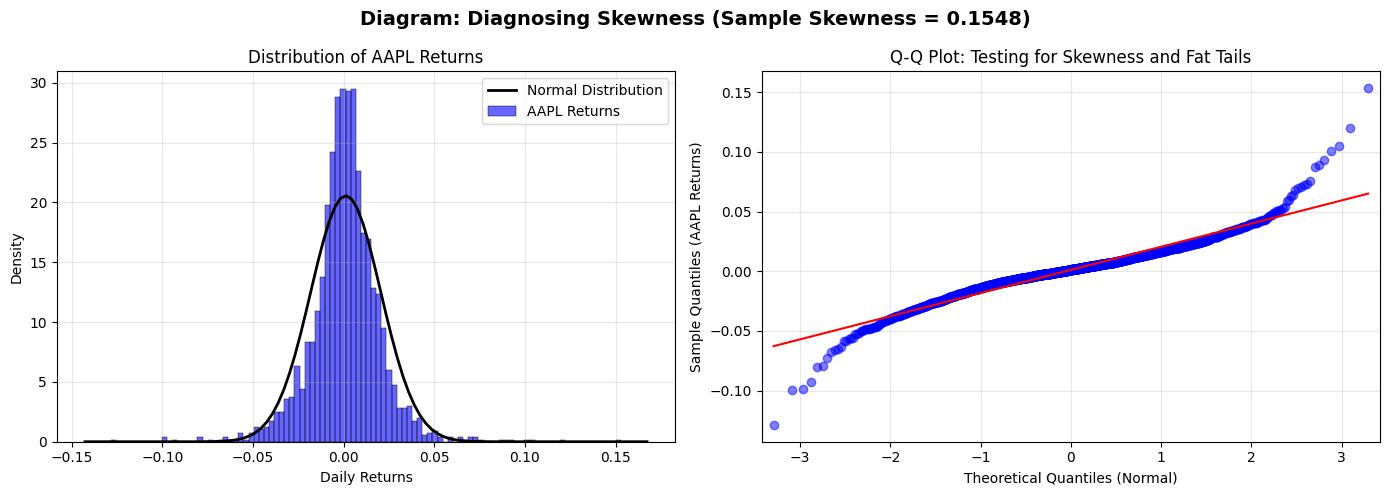

In [ ]:
returns = aapl_data['Returns'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Histogram vs Normal Distribution ---
sns.histplot(returns, bins=100, kde=False, stat='density', color='blue', alpha=0.6, label='AAPL Returns', ax=axes[0])
mu, std = stats.norm.fit(returns)
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'k', linewidth=2, label='Normal Distribution')

axes[0].set_title("Distribution of AAPL Returns")
axes[0].set_xlabel("Daily Returns")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#  Q-Q Plot
sm.qqplot(returns, line='s', ax=axes[1], markerfacecolor='blue', markeredgecolor='blue', alpha=0.5)

axes[1].set_title("Q-Q Plot: Testing for Skewness and Fat Tails")
axes[1].set_xlabel("Theoretical Quantiles (Normal)")
axes[1].set_ylabel("Sample Quantiles (AAPL Returns)")
axes[1].grid(True, alpha=0.3)

# Formatting the overall figure
plt.suptitle(f"Diagram: Diagnosing Skewness (Sample Skewness = {returns.skew():.4f})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Diagnosis**

* **Visual Test:** Plot the data using a Q-Q Plot; if the tails of the sample data visibly peel away from the theoretical normal straight line, the data is skewed.
* **Statistical Test:** Calculate the sample skewness coefficient or run the Jarque-Bera test, which jointly checks skewness and kurtosis against a normal distribution.

**Damage**
Traditional risk models (like standard Black-Scholes) assume returns are normally distributed and perfectly symmetric. Ignoring negative skewness causes risk managers to drastically underestimate downside risk, resulting in dangerously underpriced out-of-the-money put options and inadequate crash hedges.

**Directions**

* **Asymmetric Volatility Models:** Utilize models designed to capture asymmetric market shocks, such as EGARCH (Exponential GARCH) or GJR-GARCH.
* **Heavy-Tailed Distributions:** Specify a skewed distribution for the model's error terms, such as a Skewed Student-t distribution, rather than a standard normal distribution.

##3. Sensitivity to Outliers
**Definition**
An observation $x_t$ at time $t$ is considered an outlier if its absolute deviation from the mean exceeds a specified threshold, often defined by a Z-score $> 3$:


$$|Z_t| = \left| \frac{x_t - \mu}{\sigma} \right| > 3$$

**Description**
In financial time series, outliers are extreme daily returns (market shocks or crashes) that deviate significantly from typical fluctuations. Rather than occurring randomly, they often appear in dense "clusters" during periods of high market distress.

**Demonstration & Diagram**




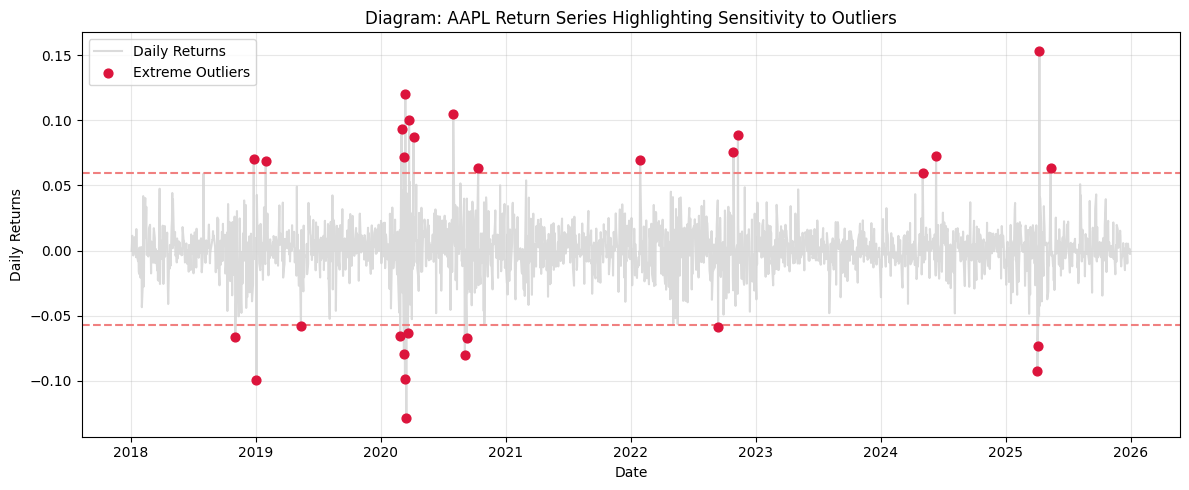

In [ ]:
returns = aapl_data['Returns'].dropna()

# Calculate Z-scores and define threshold
threshold = 3
z_scores = np.abs(stats.zscore(returns))
outliers = returns[z_scores > threshold]

# Calculate mean and standard deviation for the threshold lines
mean_return = returns.mean()
std_return = returns.std()
upper_bound = mean_return + (threshold * std_return)
lower_bound = mean_return - (threshold * std_return)


plt.figure(figsize=(12, 5))

# Plot the base returns
plt.plot(returns.index, returns, color='lightgray', label='Daily Returns', alpha=0.8)

# Highlight the outliers in red
plt.scatter(outliers.index, outliers, color='crimson', s=40, label='Extreme Outliers', zorder=5)

# Add horizontal dashed lines for the Z-score thresholds
plt.axhline(upper_bound, color='lightcoral', linestyle='--', linewidth=1.5)
plt.axhline(lower_bound, color='lightcoral', linestyle='--', linewidth=1.5)

# Format the plot to meet professional rubric standards
plt.title("Diagram: AAPL Return Series Highlighting Sensitivity to Outliers")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Diagnosis**

* **Visual Test:** Plot the return series chronologically with statistical threshold lines (e.g., $\pm 3$ standard deviations). Outliers will visually pierce these bounds, often clustering together during specific historical events.
* **Statistical Test:** Calculate Z-scores for the time series or use rolling standard deviations to statistically flag days with extreme abnormal returns.

**Damage**
Because standard volatility models rely on squared returns, they are hyper-sensitive to large numbers. A single extreme outlier (like a COVID-19 crash day) will pull the model's parameters toward itself, causing the model to artificially over-inflate future volatility forecasts long after the actual market panic has subsided.

**Directions**

* **Robust Models:** Upgrade from assuming normal distributions to using heavy-tailed distributions (like the Student's t-distribution or GED) within your GARCH volatility models.
* **Data Treatment:** Apply Winsorization, which caps extreme return values at a specific percentile (e.g., the 1st and 99th percentiles) before running the model.



### 4. Overfitting

**Definition**
Overfitting occurs when a model is excessively complex and captures random noise rather than the underlying data generating process. Mathematically, it is defined by a low in-sample error but a high out-of-sample error:


$$Error_{train} \approx 0 \quad \text{but} \quad Error_{test} \gg Error_{train}$$

**Description**
An overfitted model perfectly memorizes historical data but completely fails to generalize to new, unseen data. In econometrics, this typically happens when you include too many parameters relative to the number of observations.

**Demonstration & Diagram (Python Code)**
To clearly demonstrate this, let's take a 100-day slice of our AAPL data. We will train a simple model (a straight line) and an overly complex model (a 15th-degree polynomial) on the first 80 days, and see how they predict the next 20 days.




--- Demonstration: Overfitting (Mean Squared Error) ---
Simple Model  -> Train Error: 27.97 | Test Error: 166.13
Overfit Model -> Train Error: 7.53 | Test Error: 29317626973.63

Notice the Overfit Model has a lower Train Error, but a massive Test Error!


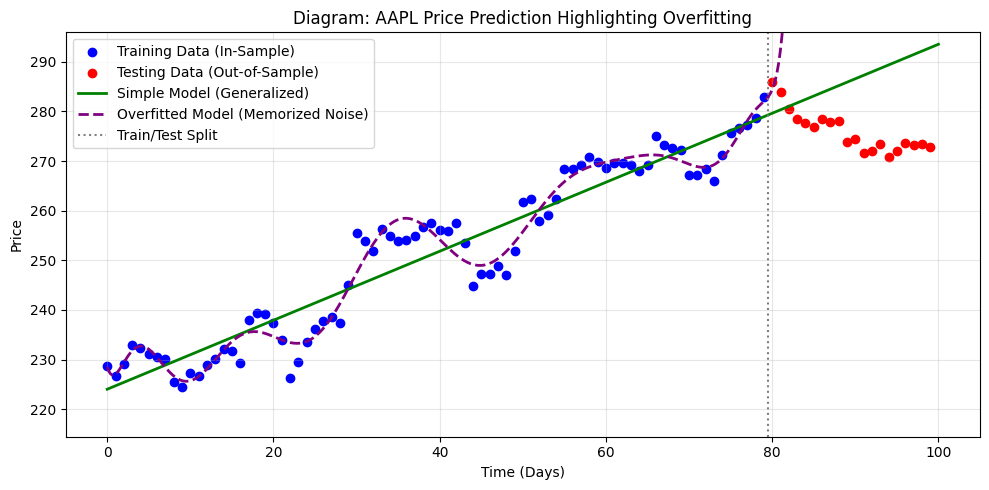

In [ ]:
sample_data = aapl_data['Close'].iloc[-100:].values.flatten()
X = np.arange(len(sample_data))
y = sample_data

# Split into Training (first 80 days) and Testing (last 20 days)
X_train, X_test = X[:80], X[80:]
y_train, y_test = y[:80], y[80:]

# Fit a Simple Model (Degree 1) and an Overfitted Model (Degree 15)
p_simple = np.poly1d(np.polyfit(X_train, y_train, 1))
p_overfit = np.poly1d(np.polyfit(X_train, y_train, 15))

print("--- Demonstration: Overfitting (Mean Squared Error) ---")
print(f"Simple Model  -> Train Error: {mean_squared_error(y_train, p_simple(X_train)):.2f} | Test Error: {mean_squared_error(y_test, p_simple(X_test)):.2f}")
print(f"Overfit Model -> Train Error: {mean_squared_error(y_train, p_overfit(X_train)):.2f} | Test Error: {mean_squared_error(y_test, p_overfit(X_test)):.2f}")
print("\nNotice the Overfit Model has a lower Train Error, but a massive Test Error!")

plt.figure(figsize=(10, 5))

# Ploting the actual data points
plt.scatter(X_train, y_train, color='blue', label='Training Data (In-Sample)')
plt.scatter(X_test, y_test, color='red', label='Testing Data (Out-of-Sample)')

# Generating points for smooth curve plotting
X_plot = np.linspace(0, 100, 500)

# Ploting the models
plt.plot(X_plot, p_simple(X_plot), color='green', linewidth=2, label='Simple Model (Generalized)')
plt.plot(X_plot, p_overfit(X_plot), color='purple', linewidth=2, linestyle='--', label='Overfitted Model (Memorized Noise)')

# Formatting the plot
plt.axvline(x=79.5, color='gray', linestyle=':', label='Train/Test Split')
plt.ylim(y.min() - 10, y.max() + 10)
plt.title("Diagram: AAPL Price Prediction Highlighting Overfitting")
plt.xlabel("Time (Days)")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



**Diagnosis**

* **Out-of-Sample Testing:** Split your dataset into training and testing periods. If the model has a near-zero error on the training data but a massive error on the unseen testing data, it is overfitted.
* **Information Criteria:** Calculate the Akaike Information Criterion (AIC) or Bayesian Information Criterion (BIC). High values indicate the model has too many unnecessary parameters.

**Damage**
An overfitted model creates a dangerous illusion of safety. Because it perfectly memorizes historical noise, risk managers and traders will confidently deploy capital based on flawless backtests, only to suffer catastrophic financial losses when the model completely fails to predict actual future volatility in live markets.

**Directions**

* **Cross-Validation:** Always evaluate models using out-of-sample testing or k-fold cross-validation to ensure they generalize to new market conditions.
* **Regularization:** Apply techniques like Ridge or Lasso regression, which mathematically penalize complexity and shrink the impact of less important variables.
* **Parsimony:** Adopt the principle of parsimony always select the simplest model (e.g., standard GARCH(1,1)) that adequately explains the volatility over highly complex, multi-parameter variations.


### Bibliography

Brooks, Chris. *Introductory Econometrics for Finance*. 4th ed., Cambridge University Press, 2019.

Gujarati, Damodar N., and Dawn C. Porter. *Basic Econometrics*. 5th ed., McGraw-Hill Education, 2009.

Hull, John C. *Options, Futures, and Other Derivatives*. 11th ed., Pearson, 2021.

Tsay, Ruey S. *Analysis of Financial Time Series*. 3rd ed., John Wiley & Sons, 2010.
